<a href="https://colab.research.google.com/github/amit-sw/colab_notebooks/blob/main/20260727_Landscape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up

We need to run all cells in-order from top to bottom.

Please change **TESTMODE = False** to **TESTMODE = True** during development if you want to test individual Agents.

In [1]:
!pip install langchain_openai langgraph pydantic openai langchain_core langchain_community --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
import os
from google.colab import userdata
OPENAI_API_KEY=userdata.get('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY']=OPENAI_API_KEY
TESTMODE = False

In [3]:
from IPython.display import display, Markdown
from openai import OpenAI
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

import operator
from typing import Annotated

import uuid
from enum import Enum

from langchain_core.messages import SystemMessage, BaseMessage, HumanMessage, AIMessage

## Creating the graph (and testing)

We are creating the data structures for **Structured Output** from LLMs for missing information in the initial user specification.

We then define the overall Graph and then define each Agent one-by-one. For each Agent, we also write corresponding code to test the Agent in isolation.


In [4]:
class InformationCategory(str, Enum):
    ZONE = "zone"
    WATER = "water"
    ORIENTATION = "orientation"


class InformationElement(BaseModel):
    category: InformationCategory
    description: str = Field(
        description="A concise explanation of the missing information."
    )

class InputReviewResult(BaseModel):
    is_complete: bool = Field(
        description=(
            "True when the user has provided sufficient zone, water, "
            "and orientation information."
        )
    )
    information_needed: list[InformationElement] = Field(
        description=(
            "Missing information. This must be empty when is_complete is true."
        )
    )

In [5]:
class AgentState(BaseModel):
    """State of the agent."""
    messages: Annotated[list[dict[str, str]],operator.add] = Field(default_factory=list)
    user_spec: str = ""
    input_review: InputReviewResult | None = None
    response: str = ""
    category: str = ""
    lastAgent: str = ""
    finalDesign: str = ""

In [6]:
class LandscapeAgent():
    """A chatbot agent that interacts with users."""

    def __init__(self, api_key: str):
        #self.model = ChatOpenAI(model_name="gpt-5-nano", openai_api_key=api_key)
        self.client = OpenAI(api_key=api_key)
        workflow = StateGraph(AgentState)
        workflow.add_node("initialInput", self.initialInput)
        workflow.add_node("inputReview", self.inputReview)
        workflow.add_node("firstDesign", self.firstDesign)
        workflow.add_node("reviewDesign", self.reviewDesign)
        workflow.add_node("finalDesign", self.finalDesign)

        workflow.add_edge(START, "initialInput")
        workflow.add_edge("initialInput", "inputReview")
        workflow.add_edge("inputReview", "firstDesign")
        workflow.add_edge("firstDesign", "reviewDesign")
        workflow.add_edge("reviewDesign", "finalDesign")
        workflow.add_edge("finalDesign", END)

        self.graph = workflow.compile()

In [7]:
def initialInput(self, state: AgentState):
    print("Initial Input  agent processing....")
    LANDSCAPE_DESIGN_INPUT_PROMPT = f"""
    You are a master gardener.
    Good landscape design requires (a) Zone, (b) water available, (c) orientation.
    Craft a message to ask the user for this information.
    """
    response = self.client.responses.create(
        model="gpt-5-mini",
        instructions=LANDSCAPE_DESIGN_INPUT_PROMPT,
        input=state.messages,
        store=False
    )
    user_response = input(f"{response.output_text}\n")
    #print(f"DEBUG: AAAA. User response: {user_response}")

    return {"user_spec": f"{user_response}",
            "messages": [
                {"role": "assistant", "content": response.output_text},
                 {"role": "user", "content": user_response},
            ],
            "lastAgent": "inputReview"}
LandscapeAgent.initialInput = initialInput

In [8]:
if TESTMODE:
  app=LandscapeAgent(OPENAI_API_KEY)
  test_state = AgentState(
      messages=[{"role":"user","content":"I need help with my landscape"}],
  )

  result = app.graph.nodes["initialInput"].invoke(test_state)

  print(f"Returns: {result['user_spec']}")

In [9]:
def inputReview(self, state: AgentState):
    print("Input review agent processing....")
    user_spec=state.user_spec
    print(f"DEBUG: User spec: {user_spec}")
    INPUT_REVIEW_PROMPT = """
    Review the user's landscape-design requirements.

    Sufficient input must include:
    1. The climate or USDA hardiness zone.
    2. The amount of water available or desired irrigation level.
    3. The site's orientation or sunlight exposure.

    Set is_complete to true only when all three categories are sufficiently
    specified.

    If is_complete is true:
    - information_needed must be an empty list.

    If is_complete is false:
    - Include exactly one InformationElement for each missing or unclear category.
    - Do not include categories that are already sufficiently specified.
    - Make each description a concise question or explanation of what is needed.
    """
    msg=[]
    msg.extend(state.messages)
    new_msg={"role":"user","content":f"Review the following landscape specification:{user_spec}"}
    msg.append(new_msg)
    response = self.client.responses.parse(
        model="gpt-5-mini",
        instructions=INPUT_REVIEW_PROMPT,
        input=msg,
        text_format=InputReviewResult,
        store=False
    )
    #llm_messages1 = create_openai_msg(SMALLTALK_PROMPT, state.messages)
    review=response.output_parsed
    if(review.is_complete):
      print("AAA DEBUG:", review.model_dump(mode="json"))
      return {"input_review": review,
              "messages": [
                  {
                    "role": "assistant",
                    "content": "Thanks—your landscape requirements are complete.",
                    }
                ],
              "lastAgent": "inputReview"}
    follow_up_question=review.information_needed[0].description
    extra_info=input(follow_up_question)
    extra_msg={"role":"user","content":extra_info}
    msg.append(extra_msg)
    response2 = self.client.responses.parse(
        model="gpt-5-mini",
        instructions=INPUT_REVIEW_PROMPT,
        input=msg,
        text_format=InputReviewResult,
        store=False
    )
    review2=response2.output_parsed
    new_turns = [
        {"role": "assistant", "content": follow_up_question},
        {"role": "user", "content": extra_info},
        #{"role": "assistant", "content": review2},
    ]
    #print("BBB DEBUG:", review.model_dump(mode="json"))
    print("Finished Input review agent")
    return { #"input_review": review,"extra_info":extra_info,"input_review2": review2,
            "messages": new_turns,
            "lastAgent": "inputReview"}
LandscapeAgent.inputReview = inputReview

In [10]:
if TESTMODE:
  app=LandscapeAgent(OPENAI_API_KEY)
  test_state = AgentState(
      messages=[
          {'role': 'assistant',
          'content': 'Great — I can help. To design something that will thrive I need three key facts:\n\n1) Zone — your plant hardiness zone (USDA or Sunset) or your ZIP/postal code and nearest city/state so I can look it up for you.  \n2) Water available — your water source (municipal, well, rain-harvest, greywater), whether you have irrigation (drip, sprinkler, none), any watering limits or drought restrictions, and whether you prefer low-water/ xeriscape plants.  \n3) Orientation — which way the yard/bed faces (which side of the house is north/south/east/west), typical sun/shade patterns through the day (full sun, morning sun/afternoon shade, full shade), and whether the site is flat or sloped.\n\nIf you don’t know some of these, that’s fine — you can send a photo, a simple sketch, or your general location and I’ll help figure it out. Also tell me any preferences (style, maintenance level, pets/kids, budget) so the plan fits your needs.'},
          {'role': 'user', 'content': 'Zone 3. Looks east.'}
          ],
      user_spec="""
          Zone 3. Looks east.
      """,
  )

  result = app.graph.nodes["inputReview"].invoke(test_state)

  result

In [11]:
def firstDesign(self, state: AgentState):
    print("First Design  agent processing....")
    FIRST_DESIGN_PROMPT="""
    Create a fully-formed landscape design suggestion.

    If possible, factor in:
    1. The climate or USDA hardiness zone.
    2. The amount of water available or desired irrigation level.
    3. The site's orientation or sunlight exposure.

    We want to use native plants as much as possible, and not use too much water for irrigation.
    """
    msg=[]
    msg.extend(state.messages)
    #new_msg={"role":"user","content":f"Review the following landscape specification:{user_spec}"}
    #msg.append(new_msg)
    response = self.client.responses.create(
        model="gpt-5-mini",
        instructions=FIRST_DESIGN_PROMPT,
        input=msg,
        store=False
    )
    #llm_response = response.output_text

    return {
            "messages": [
                {"role": "assistant", "content": FIRST_DESIGN_PROMPT},
                {"role": "assistant", "content": response.output_text},
            ],
            "lastAgent": "firstDesign"}
LandscapeAgent.firstDesign = firstDesign

In [12]:
if TESTMODE:
  app=LandscapeAgent(OPENAI_API_KEY)
  test_state = AgentState(
      messages=[
          {'role': 'assistant',
          'content': 'Great — I can help. To design something that will thrive I need three key facts:\n\n1) Zone — your plant hardiness zone (USDA or Sunset) or your ZIP/postal code and nearest city/state so I can look it up for you.  \n2) Water available — your water source (municipal, well, rain-harvest, greywater), whether you have irrigation (drip, sprinkler, none), any watering limits or drought restrictions, and whether you prefer low-water/ xeriscape plants.  \n3) Orientation — which way the yard/bed faces (which side of the house is north/south/east/west), typical sun/shade patterns through the day (full sun, morning sun/afternoon shade, full shade), and whether the site is flat or sloped.\n\nIf you don’t know some of these, that’s fine — you can send a photo, a simple sketch, or your general location and I’ll help figure it out. Also tell me any preferences (style, maintenance level, pets/kids, budget) so the plan fits your needs.'},
          {'role': 'user', 'content': 'Zone 3. Looks east.'},
          {'role': 'assistant',
          'content': 'Please specify water availability and desired irrigation level (municipal/well/rainwater/none), irrigation type if any (drip/sprinkler/none), any watering restrictions, or whether you prefer low‑water/xeriscape planting.'},
            {'role': 'user', 'content': 'Drip irrigation'},
          ],
      user_spec="""
          Zone 3. Looks east.
      """,
  )

  result = app.graph.nodes["firstDesign"].invoke(test_state)

  result

In [13]:
def reviewDesign(self, state: AgentState):
    print(" reviewDesign  agent processing....")

    REVIEW_DESIGN_PROMPT="""
    Review the proposed design. In particular, focus on

    1. No citrus fruits - they taste bad
    2. Only perenial flowers

    Provide a short succint feedback with recommended changes.
    """
    msg=[]
    msg.extend(state.messages)
    #new_msg={"role":"user","content":f"Review the following landscape specification:{user_spec}"}
    #msg.append(new_msg)
    response = self.client.responses.create(
        model="gpt-5-mini",
        instructions=REVIEW_DESIGN_PROMPT,
        input=msg,
        store=False
    )
    #llm_response = response.output_text

    return {
            "messages": [
                {"role": "assistant", "content": REVIEW_DESIGN_PROMPT},
                {"role": "assistant", "content": response.output_text},
            ],
            "lastAgent": "reviewDesign"}
LandscapeAgent.reviewDesign = reviewDesign



In [14]:
if TESTMODE:
  app=LandscapeAgent(OPENAI_API_KEY)
  test_state = AgentState(
      messages=[
          {'role': 'assistant',
          'content': 'Great — I can help. To design something that will thrive I need three key facts:\n\n1) Zone — your plant hardiness zone (USDA or Sunset) or your ZIP/postal code and nearest city/state so I can look it up for you.  \n2) Water available — your water source (municipal, well, rain-harvest, greywater), whether you have irrigation (drip, sprinkler, none), any watering limits or drought restrictions, and whether you prefer low-water/ xeriscape plants.  \n3) Orientation — which way the yard/bed faces (which side of the house is north/south/east/west), typical sun/shade patterns through the day (full sun, morning sun/afternoon shade, full shade), and whether the site is flat or sloped.\n\nIf you don’t know some of these, that’s fine — you can send a photo, a simple sketch, or your general location and I’ll help figure it out. Also tell me any preferences (style, maintenance level, pets/kids, budget) so the plan fits your needs.'},
          {'role': 'user', 'content': 'Zone 3. Looks east.'},
          {'role': 'assistant',
          'content': 'Please specify water availability and desired irrigation level (municipal/well/rainwater/none), irrigation type if any (drip/sprinkler/none), any watering restrictions, or whether you prefer low‑water/xeriscape planting.'},
            {'role': 'user', 'content': 'Drip irrigation'},
          {'role': 'assistant',
          'content': '''
              Thanks — I’ll assume you want a low‑water, mostly‑native planting for an east‑facing site in USDA Zone 3
              with drip irrigation. I’ll give a complete, ready‑to‑use design for a typical mid‑size planting bed
              (about 20 ft long × 12 ft deep) that gets strong morning sun and afternoon shade (typical “east” exposure).
              If your space is much larger/smaller or you want a different use (lawn replacement, rain garden, privacy screen),
              tell me and I’ll adapt.\n\nDesign goals\n- Use mostly regionally native, cold‑hardy (Zone 3) plants.\n-
              Low supplemental irrigation once established (drip used for establishment and occasional deep watering).\n
              - Wildlife and pollinator value, seasonal interest (spring flowers, summer blooms, fall color, winter structure).\n
              - Low maintenance: mulched, grouped by water need, minimal fertilizer.\n\nSite plan (20\' × 12\') — concept\n
              - Back row (near structure or fence, 6–8 ft from edge): 1 small native tree + 2–3 medium shrubs
              for structure and spring interest.\n- Mid row (4–6 ft tall shrubs/perennials):
                massed shrubs and taller perennials for summer color.\n- Front row (low perennials/groundcovers/ornamental grasses):
                groundcovers and clumping grasses for texture and low water use.\n- Mulch 2–3" with wood chips or shredded bark;
                place drip lines in separate zones (establishment vs. long‑term low‑water plants).\n\nPlant palette
                (Zone 3, tolerant of morning sun/afternoon shade, low water once established)\n
                Trees / large shrubs\n- Amelanchier alnifolia (Saskatoon/serviceberry) — small tree, spring white flowers,
                edible berries, excellent wildlife value. Plant 1 at back center.
                Spacing: 12–18 ft mature but single specimen here.\n\nMedium shrubs\n
                - Cornus sericea (red‑osier dogwood) — winter twig color, tolerates partial shade;
                plant 2 at rear corners or staggered. (Can be cut back for stems.)\n
                - Potentilla fruticosa (shrubby cinquefoil) — sunny/part‑shade tolerant, long bloom, very drought resistant;
                plant 2–3 in mid row.\n- Shepherdia canadensis (buffaloberry) — very drought tolerant, wildlife value;
                1–2 if you want fruiting shrub.\n\nPerennials (fill mid and front rows)\n
                - Echinacea angustifolia / Echinacea purpurea (purple coneflower) — pollinator magnet; tolerates some shade
                but likes morning sun.\n- Rudbeckia hirta (black‑eyed Susan) — long bloom, drought tolerant.\n
                - Solidago spp. (goldenrod) — late‑season nectar, partial shade tolerant.\n- Aster spp. (Symphyotrichum spp.) —
                fall blooms, good in partial shade.\n
                - Heuchera richardsonii (native alumroot) or Heuchera americana (where appropriate) — good front row, shade tolerant.
                '''},
          ],
      user_spec="""
          Zone 3. Looks east.
      """,
  )

  result = app.graph.nodes["reviewDesign"].invoke(test_state)

  result

In [15]:
def finalDesign(self, state: AgentState):
    print(" finalDesign  agent processing....")
    FINAL_DESIGN_PROMPT="""
    Create a final design, based on all the discussion so far.
    """
    msg=[]
    msg.extend(state.messages)
    #new_msg={"role":"user","content":f"Review the following landscape specification:{user_spec}"}
    #msg.append(new_msg)
    response = self.client.responses.create(
        model="gpt-5-mini",
        instructions=FINAL_DESIGN_PROMPT,
        input=msg,
        store=False
    )
    #llm_response = response.output_text

    return {
            "messages": [
                {"role": "assistant", "content": FINAL_DESIGN_PROMPT},
                {"role": "assistant", "content": response.output_text},
            ],
            "finalDesign":response.output_text,
            "lastAgent": "finalDesign"}
LandscapeAgent.finalDesign = finalDesign

In [16]:
if TESTMODE:
  app=LandscapeAgent(OPENAI_API_KEY)
  test_state = AgentState(
      messages=[
          {'role': 'assistant',
          'content': 'Great — I can help. To design something that will thrive I need three key facts:\n\n1) Zone — your plant hardiness zone (USDA or Sunset) or your ZIP/postal code and nearest city/state so I can look it up for you.  \n2) Water available — your water source (municipal, well, rain-harvest, greywater), whether you have irrigation (drip, sprinkler, none), any watering limits or drought restrictions, and whether you prefer low-water/ xeriscape plants.  \n3) Orientation — which way the yard/bed faces (which side of the house is north/south/east/west), typical sun/shade patterns through the day (full sun, morning sun/afternoon shade, full shade), and whether the site is flat or sloped.\n\nIf you don’t know some of these, that’s fine — you can send a photo, a simple sketch, or your general location and I’ll help figure it out. Also tell me any preferences (style, maintenance level, pets/kids, budget) so the plan fits your needs.'},
          {'role': 'user', 'content': 'Zone 3. Looks east.'},
          {'role': 'assistant',
          'content': 'Please specify water availability and desired irrigation level (municipal/well/rainwater/none), irrigation type if any (drip/sprinkler/none), any watering restrictions, or whether you prefer low‑water/xeriscape planting.'},
            {'role': 'user', 'content': 'Drip irrigation'},
          {'role': 'assistant',
          'content': '''
              Thanks — I’ll assume you want a low‑water, mostly‑native planting for an east‑facing site in USDA Zone 3
              with drip irrigation. I’ll give a complete, ready‑to‑use design for a typical mid‑size planting bed
              (about 20 ft long × 12 ft deep) that gets strong morning sun and afternoon shade (typical “east” exposure).
              If your space is much larger/smaller or you want a different use (lawn replacement, rain garden, privacy screen),
              tell me and I’ll adapt.\n\nDesign goals\n- Use mostly regionally native, cold‑hardy (Zone 3) plants.\n-
              Low supplemental irrigation once established (drip used for establishment and occasional deep watering).\n
              - Wildlife and pollinator value, seasonal interest (spring flowers, summer blooms, fall color, winter structure).\n
              - Low maintenance: mulched, grouped by water need, minimal fertilizer.\n\nSite plan (20\' × 12\') — concept\n
              - Back row (near structure or fence, 6–8 ft from edge): 1 small native tree + 2–3 medium shrubs
              for structure and spring interest.\n- Mid row (4–6 ft tall shrubs/perennials):
                massed shrubs and taller perennials for summer color.\n- Front row (low perennials/groundcovers/ornamental grasses):
                groundcovers and clumping grasses for texture and low water use.\n- Mulch 2–3" with wood chips or shredded bark;
                place drip lines in separate zones (establishment vs. long‑term low‑water plants).\n\nPlant palette
                (Zone 3, tolerant of morning sun/afternoon shade, low water once established)\n
                Trees / large shrubs\n- Amelanchier alnifolia (Saskatoon/serviceberry) — small tree, spring white flowers,
                edible berries, excellent wildlife value. Plant 1 at back center.
                Spacing: 12–18 ft mature but single specimen here.\n\nMedium shrubs\n
                - Cornus sericea (red‑osier dogwood) — winter twig color, tolerates partial shade;
                plant 2 at rear corners or staggered. (Can be cut back for stems.)\n
                - Potentilla fruticosa (shrubby cinquefoil) — sunny/part‑shade tolerant, long bloom, very drought resistant;
                plant 2–3 in mid row.\n- Shepherdia canadensis (buffaloberry) — very drought tolerant, wildlife value;
                1–2 if you want fruiting shrub.\n\nPerennials (fill mid and front rows)\n
                - Echinacea angustifolia / Echinacea purpurea (purple coneflower) — pollinator magnet; tolerates some shade
                but likes morning sun.\n- Rudbeckia hirta (black‑eyed Susan) — long bloom, drought tolerant.\n
                - Solidago spp. (goldenrod) — late‑season nectar, partial shade tolerant.\n- Aster spp. (Symphyotrichum spp.) —
                fall blooms, good in partial shade.\n
                - Heuchera richardsonii (native alumroot) or Heuchera americana (where appropriate) — good front row, shade tolerant.
                '''},
          {'role': 'assistant',
          'content': '''
          Short summary\n- Got it: no citrus (not relevant in Zone 3 anyway) and only perennial flowering plants —
          remove the trees and shrubs from the original plan and replace them with cold‑hardy perennials,
          grasses and bulbs that perform in USDA Zone 3, east exposure, on drip irrigation.\n\nRecommended changes
          (concise)\n1. Remove woody plants: delete Amelanchier, Cornus, Potentilla, Shepherdia. These are shrubs/trees
          and violate the “only perennial flowers” rule.\n2. Replace structure with tall perennial groups and clumping
          ornamental grasses to provide height, winter structure and seasonal interest.\n3. Choose a succession of
          perennials to give spring → summer → fall blooms so you still get long season interest without shrubs.\n4.
          Keep drip irrigation but zone it: one zone for initial establishment (more frequent), then a low‑water zone
          for mature plants (deep, infrequent watering).\n\nProposed plant palette (Zone 3, east exposure, low water
          once established) — all perennial flowers/grasses/bulbs\n- Tall (back row / 3–4+ ft)\n  - Echinacea purpurea
          or E. angustifolia (purple coneflower) — pollinator magnet, summer.\n  - Rudbeckia fulgida / R. hirta (black‑eyed Susan) —
          long summer bloom.\n  - Penstemon strictus or P. digitalis (penstemon) — spring–early summer spikes.\n
          - Baptisia australis (false indigo) — spring/early summer structural blooms.\n- Mid (1.5–3 ft)\n
          - Solidago spp. (goldenrod) — late summer/fall nectar.\n  - Symphyotrichum spp. (asters) — fall color/blooms.\n
          - Achillea millefolium (yarrow) — summer, drought tolerant.\n  - Geranium sanguineum / hardy cranesbill —
          long bloom, tidy habit.\n- Front / low (6–18 in)\n  - Heuchera (alumroot) — foliage interest, shade tolerant.\n
          - Sedum spurium / Sedum telephium (stonecrop) — late summer, very low water.\n  - Phlox subulata (creeping phlox)
          or Phlox stolonifera — spring color.\n  - Allium spp. (ornamental onion bulbs) — spring accents (bulbs are perennial).\n
          - Grasses/structure (interspersed)\n  - Calamagrostis x acutiflora ‘Karl Foerster’ or Festuca idahoensis (clumping fescue)
          — winter form, texture (many are Zone 3 hardy).\n\nLayout suggestion for your 20\' × 12\' bed (brief)\n
          - Back row: repeat blocks of tall perennials (group 3–5 of same species for impact) spaced per mature width.\n
          - Mid row: masses of mid‑height perennials alternating species for succession and diversity.\n
          - Front: tight groups of low sedum, phlox and heuchera; plant allium bulbs among them for spring pop.\n
          - Interplant clumps of ornamental grass every 6–8 ft for vertical rhythm and winter interest.\n\n
          Planting density & counts (approx. for 20\'×12\')\n- Echinacea: 6 plants (spaced ~2–2.5 ft)'''},

          ],
      user_spec="""
          Zone 3. Looks east.
      """,
  )

  result = app.graph.nodes["finalDesign"].invoke(test_state)

  result

In [17]:
app=LandscapeAgent(OPENAI_API_KEY)
list(app.graph.nodes)

['__start__',
 'initialInput',
 'inputReview',
 'firstDesign',
 'reviewDesign',
 'finalDesign']

# Run the graph

We see both the final landscape design created, as well as the internal flow of messages.

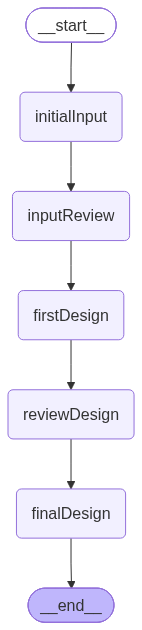

In [18]:
app=LandscapeAgent(OPENAI_API_KEY)
from IPython.display import Image
Image(app.graph.get_graph().draw_mermaid_png())

In [19]:
from IPython.display import display, Markdown

app = LandscapeAgent(OPENAI_API_KEY)
msg_list=[{"role": "user","content": "I need help with my landscape."}]
result = app.graph.invoke({"messages": msg_list})

final_design = result.get("finalDesign")

if final_design:
    display(Markdown("### Final landscape design"))
    display(Markdown(final_design))

messages = result["messages"]

Initial Input  agent processing....
Great — I can help. Good landscape design really depends on three basics: your hardiness zone, the water available, and the site orientation. Could you tell me the following?

1) Zone
- What USDA hardiness zone are you in (or give your city/zip/postal area so I can look it up)?

2) Water
- How is water supplied (municipal irrigation, well, no irrigation)?
- Any watering limits or drought restrictions where you are?
- How often do you (or will you) water beds/lawn? Any irrigation system in place?
- If you know average annual rainfall, that’s helpful too.

3) Orientation / light
- Which direction do the main planting areas face (north, south, east, west)? If you have multiple areas, list them.
- How much sun do those areas get (full sun 6+ hours, part sun/part shade, full shade)?
- Any slopes, reflective surfaces, or microclimates (hot walls, wind-exposed spots)?

Optional but very helpful: photos or a simple sketch with dimensions, soil type (sandy/lo

### Final landscape design

Final landscape design — Zone 5, hand-water, low-water, native-focused, ONLY herbaceous perennial flowers (no woody shrubs or citrus). I’ve assumed a sunny bed ~20 ft long × 8 ft deep (160 sq ft). Tell me if your bed is smaller/larger or shadier and I’ll adapt.

Design goals
- 100% perennial flowering plants (no shrubs/trees, no citrus).
- Mostly native, drought-tolerant species suited to Zone 5.
- Low irrigation after establishment; hand-watering only.
- Pollinator friendly and good seasonal interest (spring–fall flowers + winter seedheads).

Plant palette and quantities (for a 20' × 8' sunny bed)
- Back row (48–60" tall; plant on 3–4 ft centers)
  - Echinacea purpurea (Purple coneflower) — 5 plants
  - Baptisia australis (False indigo) — 2 plants
  - Symphyotrichum novae-angliae (New England aster) or Solidago spp. (Goldenrod) — 3 plants
- Middle row (24–36" tall; 18–24" spacing)
  - Rudbeckia fulgida (Black-eyed Susan) — 6 plants
  - Penstemon digitalis or P. hirsutus — 4 plants
  - Agastache foeniculum (Anise hyssop) — 3 plants
  - Monarda fistulosa (Bee balm) — 3 plants
- Front row / edge & spring interest (6–18"; 12–18" spacing)
  - Coreopsis lanceolata (Lanceleaf coreopsis) — 6 plants
  - Gaillardia aristata (Blanketflower) — 4 plants
  - Phlox subulata or Sedum ternatum (low groundcover) — 12 plugs
  - Geum triflorum (Prairie smoke) — 4 plants

Total plants ~ 52–55. Arrange in drifts (groups of 3–7) of each species rather than single specimens for best visual effect.

Layout concept (left-to-right, top-down description)
- Place tall clumps of Echinacea, Baptisia, and Aster/Solidago across the back in staggered groups (3–4 ft apart) to form a soft backdrop.
- In front of the tall clumps, alternate mid-height drifts: 2–3 Rudbeckia clustered together, then a Penstemon/Agastache/Monarda cluster, repeat across the bed. This alternation creates repeated color blocks and supports pollinators through the season.
- At the front edge, plant a continuous low band of Coreopsis, Gaillardia, Phlox plugs and Geum spaced tightly to form a flowering border and to hide mulch/soil.
- Leave small gaps for paths/visual access if you want to step in for maintenance or cut flowers.

Pot sizes / shopping guide
- Echinacea, Aster, Penstemon, Rudbeckia, Agastache, Monarda, Coreopsis, Gaillardia, Geum — 1–2 gallon pots (1 gal fine for many; 2 gal for stronger establishment)
- Baptisia — 2–3 gallon (establishes slowly; larger pot helps)
- Phlox plugs or 4–6" pots for groundcover
- Buy healthy clumps, avoid overly rootbound specimens.

Soil prep & planting
- Light prep: loosen soil across bed to 8–10" depth. If heavy clay, mix in 1–2" compost across bed (not deep berming). Avoid heavy amendments that keep soil too rich; natives prefer leaner conditions.
- Dig holes 2–3× rootball width, set crown at grade, backfill and firm gently.
- Mulch 2" (not more than 2–3") with coarse bark or shredded hardwood; keep mulch pulled an inch from crowns.

Watering & establishment (hand-water)
- First 8–12 weeks: deep soak 1–2× per week (so soil gets wet to 6–8" deep). Longer in hot/dry spells. Use a watering wand or deep soak via bucket/soaker.
- Months 3–12: reduce to once every 7–14 days as needed. Check 4–6" down — water only if dry.
- After 12–18 months: plants should be drought-tolerant and only need supplemental water during extended dry periods (every 2–6 weeks depending on heat/rainfall).
- Tip: water slowly at root zones; avoid overhead watering late in day to reduce disease risk.

Maintenance (low)
- Deadhead selectively during bloom to prolong flowering; leave some seedheads (Echinacea, Rudbeckia, Aster) for birds and winter interest.
- Divide overcrowded perennials (Coreopsis, Phlox, Monarda) every 3–4 years in spring or fall.
- Cut back stems to ~4–6" in late winter/early spring before new growth. Leave some seedheads if you want winter structure.
- Refresh mulch in spring annually.
- Minimal or no fertilizer; a light topdressing of compost in spring is sufficient.

Seasonal interest & pollinators
- Spring: Geum, early phlox
- Summer: Penstemon, Echinacea, Agastache, Monarda, Rudbeckia, Gaillardia
- Fall: Asters, Solidago — late nectar for bees and butterflies
- Winter: seedheads and stalks for birds; cut back in late winter

Optional tweaks and contingencies
- If your bed is part-shade: swap Agastache and Gaillardia for shade-tolerant perennials (Heuchera, Hosta? — note these are less drought-tolerant).
- If soil is very sandy: add a bit more compost and water a little more frequently during establishment.
- If you want lower maintenance and fewer divisions, increase Echinacea and Baptisia (long-lived clump-formers) and reduce aggressive spreaders like Monarda.

Next steps
- If you confirm your actual bed dimensions, sun exposure (full sun/part shade), and soil type (sandy/loam/clay), I will:
  - Produce a scaled planting diagram (plant placement map),
  - Give exact spacing map and a one-season planting & maintenance calendar,
  - Provide a shopping list with exact pot sizes and approximate costs.

Would you like the scaled planting map and shopping list next?

# To see the various messages during the Agentic run

In [20]:
import json

print(json.dumps(messages, indent=2))

[
  {
    "role": "user",
    "content": "I need help with my landscape."
  },
  {
    "role": "assistant",
    "content": "Great \u2014 I can help. Good landscape design really depends on three basics: your hardiness zone, the water available, and the site orientation. Could you tell me the following?\n\n1) Zone\n- What USDA hardiness zone are you in (or give your city/zip/postal area so I can look it up)?\n\n2) Water\n- How is water supplied (municipal irrigation, well, no irrigation)?\n- Any watering limits or drought restrictions where you are?\n- How often do you (or will you) water beds/lawn? Any irrigation system in place?\n- If you know average annual rainfall, that\u2019s helpful too.\n\n3) Orientation / light\n- Which direction do the main planting areas face (north, south, east, west)? If you have multiple areas, list them.\n- How much sun do those areas get (full sun 6+ hours, part sun/part shade, full shade)?\n- Any slopes, reflective surfaces, or microclimates (hot walls,

# Create image for Final design

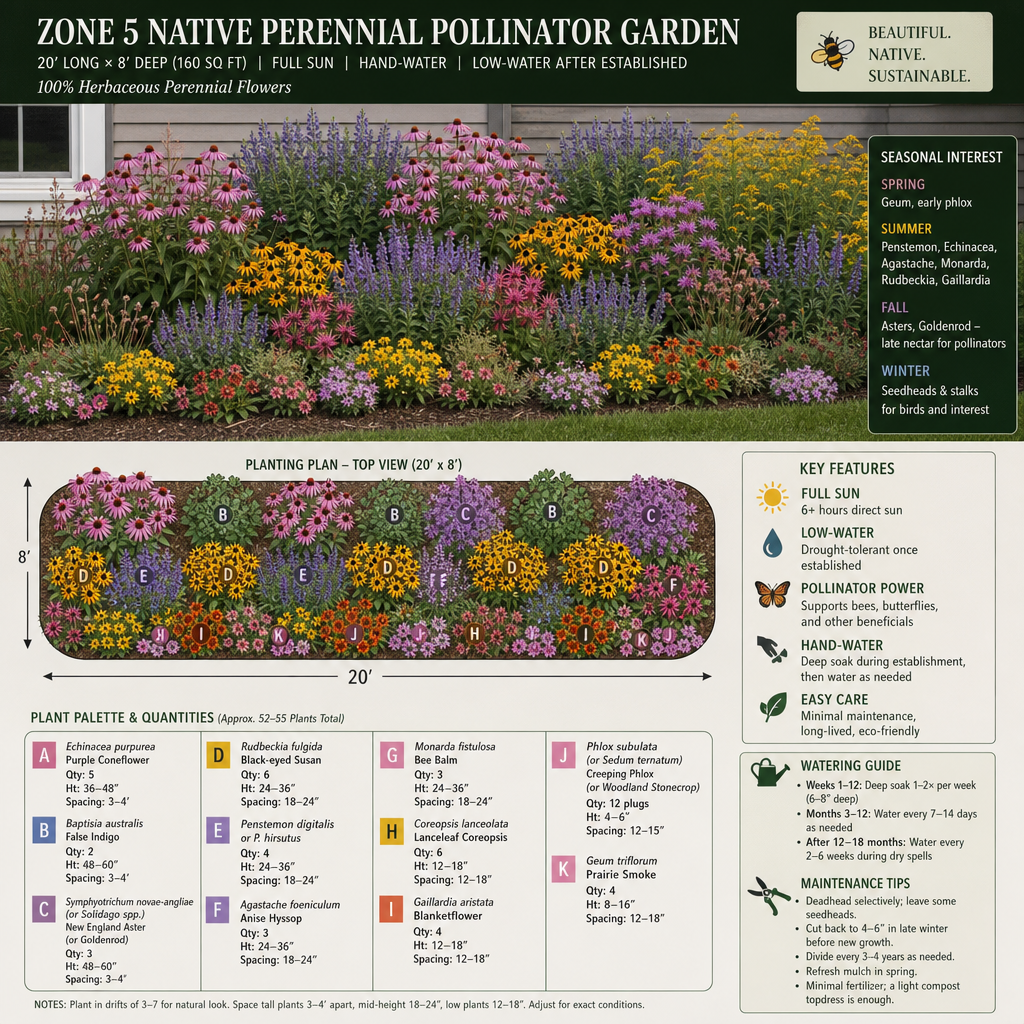

In [21]:


from openai import OpenAI
from IPython.display import display, Image
import base64

client = OpenAI()

prompt = """Create a professional looking landscape mockup based on the design created here.  """

resultImg = client.images.generate(
    model="gpt-image-2",
    prompt=prompt+final_design,
    size="1024x1024"
)

# Decode image data
image_base64 = resultImg.data[0].b64_json
image_bytes = base64.b64decode(image_base64)

#Save to file
filename="landscape_design.png"
with open(filename, "wb") as f:
    f.write(image_bytes)

# Display inline
display(Image(filename=filename))